# Malaria Detection -

This notebook performs Exploratory Data Analysis (EDA) on the Malaria Cell Images dataset, splits it into training and testing sets, train a mobilenet model and generate the metrics

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split

%matplotlib inline

## 1. Load Data and EDA

In [3]:
# Define paths
data_dir = r'C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-Detection\Data'
parasitized_path = os.path.join(data_dir, 'Parasitized')
uninfected_path = os.path.join(data_dir, 'Uninfected')

# Get file lists
parasitized_files = glob.glob(os.path.join(parasitized_path, '*.png'))
uninfected_files = glob.glob(os.path.join(uninfected_path, '*.png'))

print(f"Parasitized images: {len(parasitized_files)}")
print(f"Uninfected images: {len(uninfected_files)}")
print(f"Total images: {len(parasitized_files) + len(uninfected_files)}")

Parasitized images: 13779
Uninfected images: 13779
Total images: 27558


In [4]:
# Create a DataFrame
data = []
for p in parasitized_files:
    data.append({'path': p, 'label': 'Parasitized'})
for u in uninfected_files:
    data.append({'path': u, 'label': 'Uninfected'})

df = pd.DataFrame(data)
df.head()

,path,label
0,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Parasitized
1,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Parasitized
2,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Parasitized
3,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Parasitized
4,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Parasitized


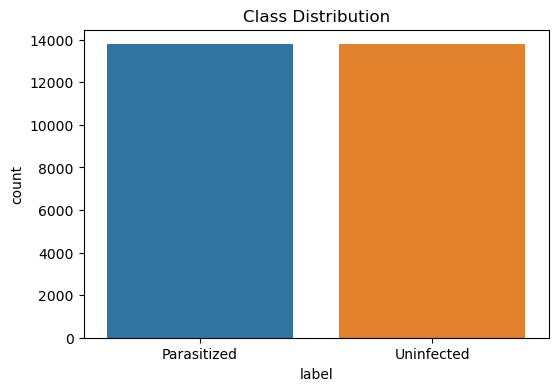

In [5]:
# Visualize Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.show()

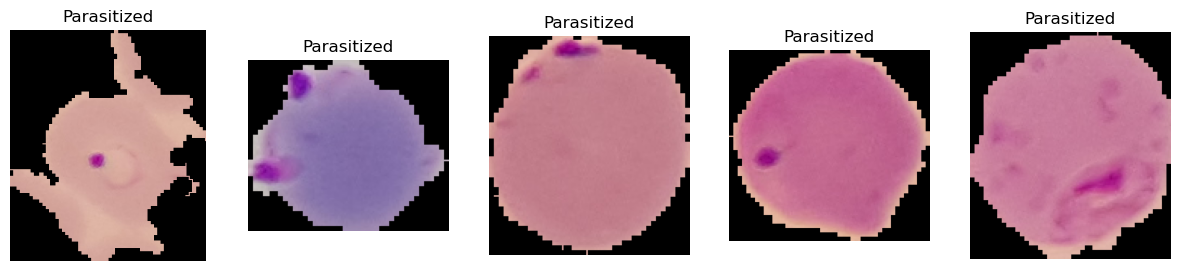

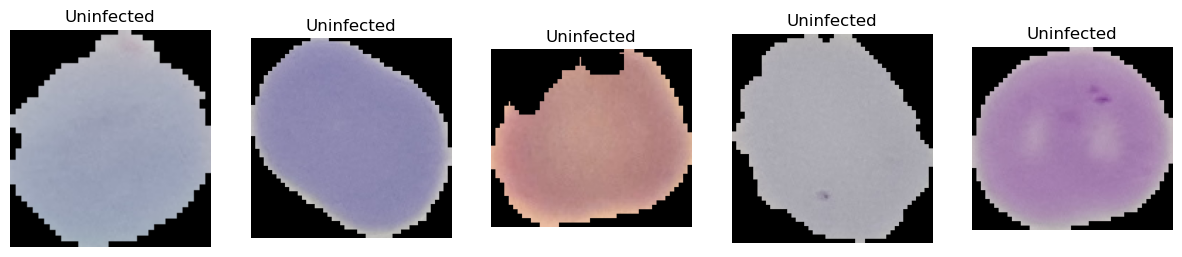

In [6]:
# Visualize Sample Images
def show_samples(label, num_samples=5):
    samples = df[df['label'] == label]['path'].sample(num_samples).values
    plt.figure(figsize=(15, 3))
    for i, img_path in enumerate(samples):
        img = Image.open(img_path)
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')
    plt.show()

show_samples('Parasitized')
show_samples('Uninfected')

## 2. Check Image Sizes

Average Width: 133.41
Average Height: 133.98


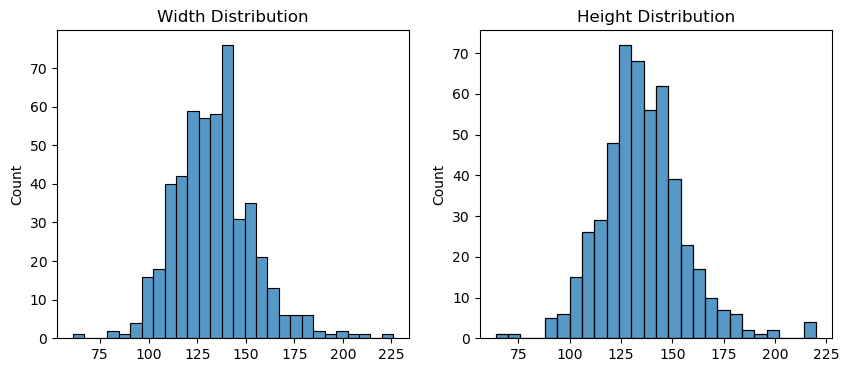

In [7]:
# Check dimensions of a few images
widths = []
heights = []

# Sample 500 images to check sizes (checking all might take time)
for img_path in df['path'].sample(500):
    img = Image.open(img_path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

print(f"Average Width: {np.mean(widths):.2f}")
print(f"Average Height: {np.mean(heights):.2f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(widths)
plt.title('Width Distribution')
plt.subplot(1, 2, 2)
sns.histplot(heights)
plt.title('Height Distribution')
plt.show()

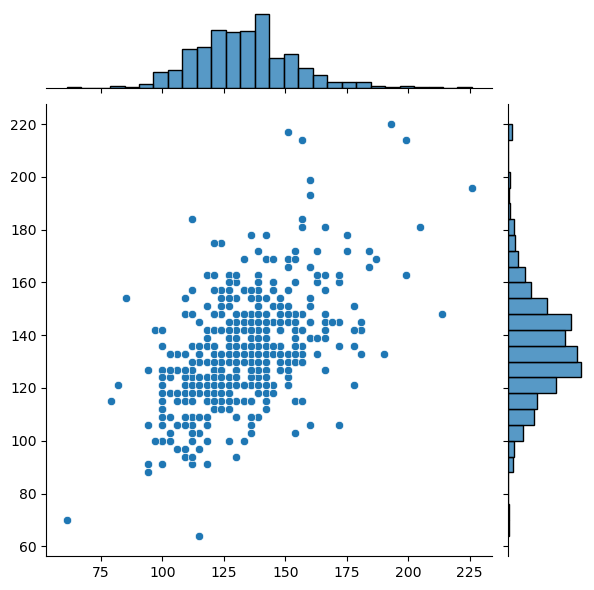

In [8]:
sns.jointplot(x=widths, y=heights, kind="scatter")
plt.show()

## 3. Split Dataset

In [9]:
# Split into Train and Test (80% Train, 20% Test)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

print(f"Train set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

# Check distribution in splits
print("\nTrain Distribution:")
print(train_df['label'].value_counts())
print("\nTest Distribution:")
print(test_df['label'].value_counts())

Train set size: 22046
Test set size: 5512

Train Distribution:
label
Parasitized    11023
Uninfected     11023
Name: count, dtype: int64

Test Distribution:
label
Uninfected     2756
Parasitized    2756
Name: count, dtype: int64


## 4. PyTorch Preparation

We will train a ResNet101 model using PyTorch.
First, we define a Custom Dataset class to load images from the file paths in our DataFrames.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models, transforms

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Define Transforms using GPU
train_transforms = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Slight color jitter for cell variation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet normalization
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [11]:
# Define Transforms using CPU
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet normalization
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [13]:
#CPU
class MalariaDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.label_map = {'Uninfected': 0, 'Parasitized': 1}
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['path']
        label_str = row['label']
        
        image = Image.open(img_path).convert('RGB')
        label = self.label_map[label_str]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Create Datasets
# Reduce dataset to 4,000 images (2,000 per class) for CPU training
train_df_small = train_df.sample(n=4000, random_state=42)
test_df_small = test_df.sample(n=1000, random_state=42)

train_dataset = MalariaDataset(train_df_small, transform=train_transforms)
test_dataset = MalariaDataset(test_df_small, transform=test_transforms)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"DataLoaders ready with batch size: {batch_size}")

DataLoaders ready with batch size: 32


In [14]:
# Check distribution in splits
print("\nTrain Distribution:")
print(train_df_small['label'].value_counts())
print("\nTest Distribution:")
print(test_df_small['label'].value_counts())


Train Distribution:
label
Parasitized    2001
Uninfected     1999
Name: count, dtype: int64

Test Distribution:
label
Uninfected     507
Parasitized    493
Name: count, dtype: int64


In [ ]:
#GPU
class MalariaDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.label_map = {'Uninfected': 0, 'Parasitized': 1}
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['path']
        label_str = row['label']
        
        image = Image.open(img_path).convert('RGB')
        label = self.label_map[label_str]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Create Datasets
train_dataset = MalariaDataset(train_df, transform=train_transforms)
test_dataset = MalariaDataset(test_df, transform=test_transforms)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"DataLoaders ready with batch size: {batch_size}")

## 5. Model Training

In [ ]:
# Define the Custom Model Class. train on GPU
class MalariaClassifierResNet(nn.Module):
    def __init__(self, num_classes=2):
        super(MalariaClassifierResNet, self).__init__()

        # Load pre-trained ResNet101
        # Using the requested weights: ResNet101_Weights.IMAGENET1K_V2
        self.base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        # Freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # ResNet structure: ... -> layer4 -> avgpool -> fc
        # We want to use the features up to layer4, then add our own pooling and classifier.
        # list(model.children())[:-2] gets all layers except avgpool and fc.
        self.features = nn.Sequential(*list(self.base_model.children())[:-2])

        # Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.output_layer = nn.Linear(2048, num_classes) # ResNet101 output channels are 2048

    def forward(self, x):
        x = self.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.output_layer(x)
        return x

# Initialize the model
model = MalariaClassifierResNet(num_classes=2)
model = model.to(device)

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
# Optimizing parameters of the output layer (and any other trainable custom layers if added)
optimizer = optim.Adam(model.output_layer.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\MECRUN/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:42<00:00, 2.41MB/s]


In [16]:
# Define the Custom Model Class. Train on CPU
class MalariaClassifierMobileNet(nn.Module):
    def __init__(self, num_classes=2):
        super(MalariaClassifierMobileNet, self).__init__()

        # Load pre-trained MobileNetV3 Large
       
        weights = models.MobileNet_V3_Large_Weights.DEFAULT
        self.base_model = models.mobilenet_v3_large(weights=weights)

        # Freeze base model parameters (feature extractor)
        for param in self.base_model.parameters():
            param.requires_grad = False

        # MobileNetV3 has a .features and a .classifier section
        # We keep the features (everything before the final pooling/classifier)
        self.features = self.base_model.features

        # MobileNetV3 Large feature output is 960 channels
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        
        # New classifier head
        self.output_layer = nn.Linear(960, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.output_layer(x)
        return x

# Initialize the model
model = MalariaClassifierMobileNet(num_classes=2)
model = model.to(device)

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()

# ONLY optimize the output_layer (the frozen features won't update)
optimizer = torch.optim.Adam(model.output_layer.parameters(), lr=0.001)

print(f"Model initialized on {device}")

Model initialized on cpu


In [ ]:
# Do not use this, use the next code block for Train

def train_model(model, criterion, optimizer, num_epochs=5):
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        
        val_loss = val_loss / len(test_loader.dataset)
        val_acc = correct_val / total_val
        test_losses.append(val_loss)
        test_accs.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
        
    return train_losses, test_losses, train_accs, test_accs

In [17]:
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [18]:
def validate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    epoch_loss = running_loss / len(test_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_test(model, test_loader, device, target_names=None):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    preds_arr = np.array(all_preds)
    labels_arr = np.array(all_labels)
    
    print("\n" + "="*30)
    print("FINAL CLASSIFICATION REPORT")
    print("="*30)
    print(classification_report(labels_arr, preds_arr, target_names=target_names))
    
    print("\nCONFUSION MATRIX:")
    print(confusion_matrix(labels_arr, preds_arr))
    
    return preds_arr, labels_arr

In [20]:
# Initialize empty lists to store metrics
train_losses, test_losses = [], []
train_accs, test_accs = [], []
epochs_recorded = []

num_epochs = 5
for epoch in range(num_epochs):
    train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, test_loader, criterion, device)
    
    # Store metrics for plotting
    train_losses.append(train_loss)
    test_losses.append(val_loss)
    train_accs.append(train_acc)
    test_accs.append(val_acc)
    epochs_recorded.append(epoch + 1)

    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')


Epoch 1/5:
  Train Loss: 0.3279 | Train Acc: 0.8795
  Val Loss: 0.2569 | Val Acc: 0.9110
Epoch 2/5:
  Train Loss: 0.2187 | Train Acc: 0.9197
  Val Loss: 0.2018 | Val Acc: 0.9330
Epoch 3/5:
  Train Loss: 0.2082 | Train Acc: 0.9220
  Val Loss: 0.1971 | Val Acc: 0.9330
Epoch 4/5:
  Train Loss: 0.1918 | Train Acc: 0.9323
  Val Loss: 0.1944 | Val Acc: 0.9330
Epoch 5/5:
  Train Loss: 0.1760 | Train Acc: 0.9395
  Val Loss: 0.1918 | Val Acc: 0.9340


## 6. Evaluation

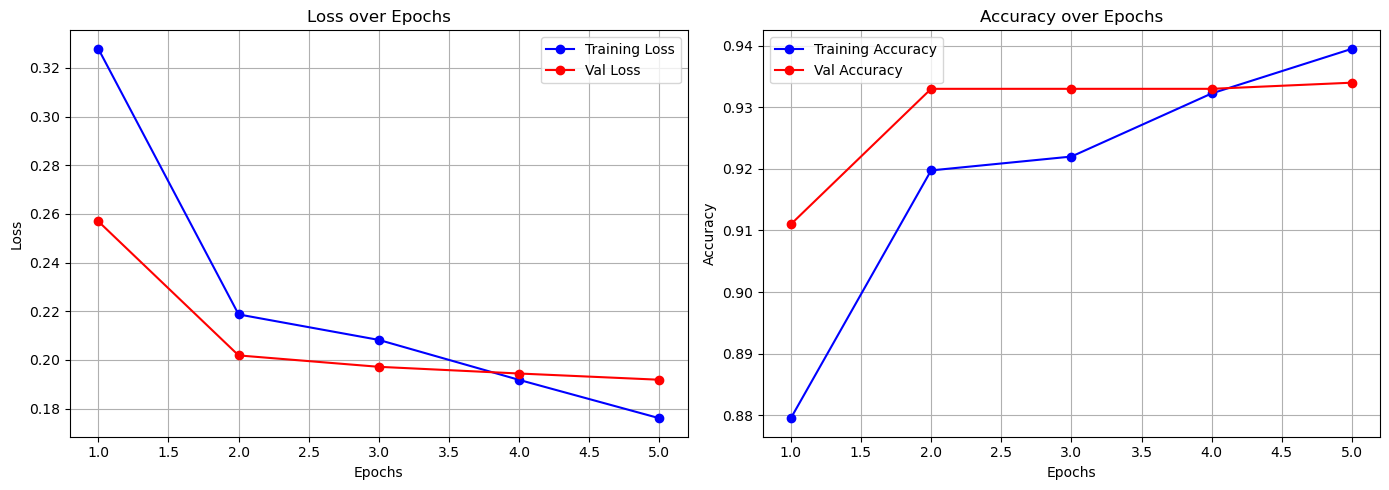

In [21]:
plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_recorded, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs_recorded, test_losses, 'r-o', label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_recorded, train_accs, 'b-o', label='Training Accuracy')
plt.plot(epochs_recorded, test_accs, 'r-o', label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

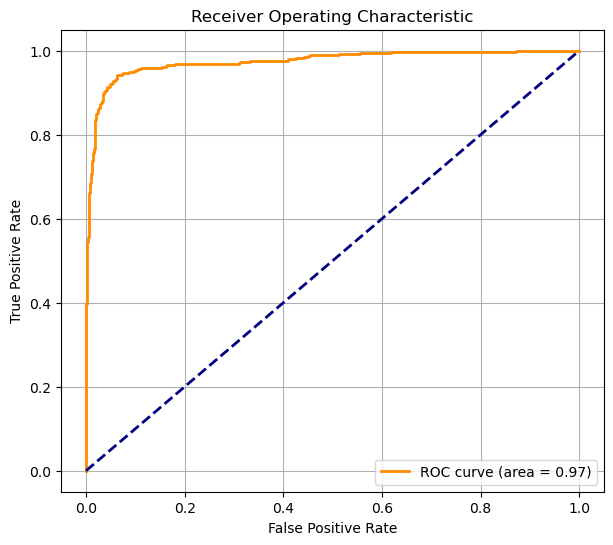

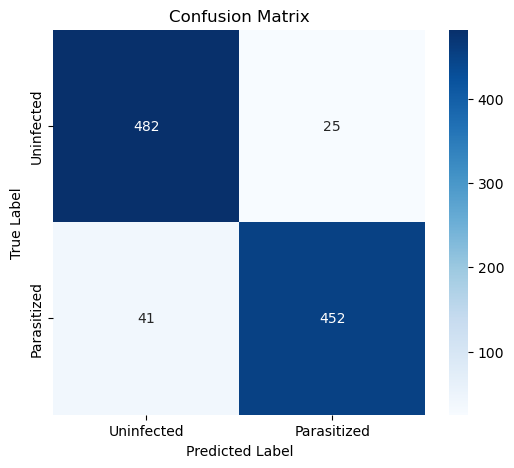


===== Final Model Performance Metrics =====
Test Accuracy: 0.9340
Test Loss: 0.1918
ROC AUC Score: 0.9748
              precision    recall  f1-score   support

  Uninfected       0.92      0.95      0.94       507
 Parasitized       0.95      0.92      0.93       493

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



In [22]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import torch.nn.functional as F
import seaborn as sns

# 1. Get predictions and raw probabilities
model.eval()
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        # Get probabilities for class 1 (Parasitized)
        probs = F.softmax(outputs, dim=1)
        all_probs.extend(probs[:, 1].cpu().numpy())
        
        # Get class predictions
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Plot ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 3. Plot Confusion Matrix Heatmap
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 4. Final Metrics Printout
print("\n===== Final Model Performance Metrics =====")
print(f"Test Accuracy: {test_accs[-1]:.4f}")
print(f"Test Loss: {test_losses[-1]:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("===========================================")
print(classification_report(all_labels, all_preds, target_names=['Uninfected', 'Parasitized']))


## Save the model

In [23]:
model_save_path = "malaria_mobilenet_v1_05.pth"

# Save the model's learned parameters
torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

Model weights saved to malaria_mobilenet_v1_05.pth


## Load and test on a New Image

In [24]:
from PIL import Image

model_save_path = "malaria_mobilenet_v1_05.pth"

loaded_model = MalariaClassifierMobileNet(num_classes=2)
loaded_model.load_state_dict(torch.load(model_save_path, map_location=device))
loaded_model.to(device)
loaded_model.eval()

C:\Users\MECRUN\AppData\Local\Temp\ipykernel_21040\573931517.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(model_save_path, map

MalariaClassifierMobileNet(
  (base_model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          )
        )
      )
      (2): InvertedResidual(
        (block): Sequential(
          (0): C

In [27]:
# 2. Function to predict a single image
def predict_image(image_path, model, transform, device):
    image = Image.open(image_path).convert('RGB')
    # Apply the same transforms used for test data
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)
        
    class_names = ['Uninfected', 'Parasitized']

    plt.imshow(image)
    plt.title(f"Prediction: {class_names[predicted.item()]}")
    plt.axis('off')

    return class_names[predicted.item()]

In [26]:
test_df.iloc[500]['path']

'C:\\Users\\MECRUN\\Desktop\\Malaria\\Malaria-Cell-Detection\\Data\\Uninfected\\C159P120ThinF_IMG_20151115_191301_cell_12.png'

The model predicts: Uninfected


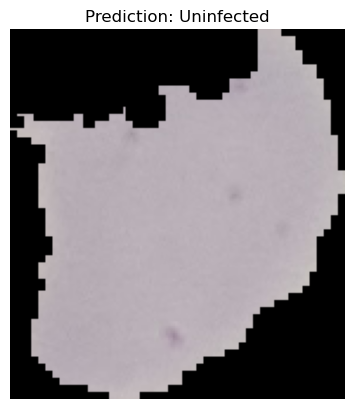

In [30]:
new_img_path = test_df.iloc[1909]['path'] #image path

result = predict_image(new_img_path, loaded_model, test_transforms, device)
print(f"The model predicts: {result}")

## Export to ONNX

In [31]:
!pip install onnx

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for onnx from https://files.pythonhosted.org/packages/8e/17/a0d7863390c1f2067d7c02dcc1477034965c32aaa1407bfcf775305ffee4/onnx-1.20.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for ml_dtypes>=0.5.0 from https://files.pythonhosted.org/packages/b4/24/70bd59276883fdd91600ca20040b41efd4902a923283c4d6edcb1de128d2/ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   -------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.17.0 requires ml-dtypes<0.5.0,>=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.


In [32]:
#import torch.onnx

# 1. Ensure model is in eval mode
loaded_model.eval()

# 2. Create a dummy input matching your model's input size (Batch, Channels, Height, Width)
# MobileNetV3 Large expects 224x224 (or 128x128 if you adjusted for CPU)
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# 3. Export the model
onnx_model_path = "malaria_model.onnx"

torch.onnx.export(
    loaded_model,               # Model being exported
    dummy_input,                # Model input (or a tuple for multiple inputs)
    onnx_model_path,            # Where it will be saved
    export_params=True,         # Store the trained parameter weights inside the model file
    opset_version=15,           # Use a modern opset version for 2026 compatibility
    do_constant_folding=True,   # Optimize the model by folding constant nodes
    verbose=True,
    input_names=['input'],      # Set name for the model's input
    output_names=['output'],    # Set name for the model's output
    dynamic_axes={'input' : {0 : 'batch_size'}, # Allow for variable batch sizes
                  'output' : {0 : 'batch_size'}}
)

print(f"Model exported to {onnx_model_path}")

Model exported to malaria_model.onnx
